In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

from pde.coeff_function import coeff_convdiff
from pde.convection_diffusion_1d import ConvectionDiffusion1D_torch as ConvectionDiffusion1D

import torch
from tree.tree import Tree
from tree_tensor.tree_tensor_torch import TreeBasedTensor
from tree_cross.tree_cross_torch import TreeCross
from tree.tree_util import balanced_binary_tupletree, linear_tupletree
from tree_als_cross.tree_als_cross_torch import TreeALSCross

### PDE test

Solve the PDE using P1 finite elements for a random parameter

Text(0, 0.5, 'A')

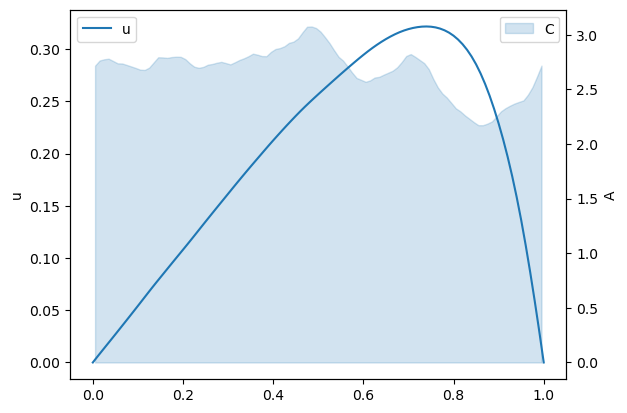

In [14]:
Nx = 100    # spatial resolution
Ny = 5       # parameter resolution
n_a_param = 200 # number of parameters for diffusion coeff
n_param = n_a_param + 1
offset = 1   # parameter mean
var = 4       # 'variance' of the parameters
v_min, v_max = -10, 10

# get random params
rng = np.random.default_rng()
y = rng.uniform(0, Ny-1, n_a_param)
v = rng.uniform(v_min, v_max)
X = np.hstack([np.arange(Nx).reshape((-1,1)), np.zeros((Nx,1)), np.tile(y, [Nx,1])])
# X = np.hstack([np.arange(Nx).reshape((-1,1)), np.tile(y, [Nx,1])])

cfun = coeff_convdiff(Nx, Ny, offset, var)

C_true = cfun(X)

PDE_fun = ConvectionDiffusion1D(Nx)

# U = PDE_fun.solve([[C_true.reshape(-1,1), np.ones((1,1))], [np.ones((1,1))]])
U = PDE_fun.solve([torch.from_numpy(C_true).reshape(-1,1), v * torch.ones((1,1)), torch.ones((1,1))], [torch.ones((1,1))])
U = np.ravel(U[0])

fig, ax = plt.subplots()
ax2 = ax.twinx()

x = np.arange(Nx+1) / Nx
midpoints = (np.arange(Nx) + 0.5) / Nx
p = ax.plot(x, U, label='u')
ax2.fill_between((np.arange(len(C_true)) + 0.5) / (len(C_true)), C_true, alpha=0.2, color=p[0].get_color(), label='C')

ax.set_ylabel('u')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
ax2.set_ylabel('A')

### Get HT approx of coefficient

In [15]:
tol = 1e-3
param_shape = tuple([Ny] * n_param)

tree = Tree.from_tupletree(balanced_binary_tupletree(n_param))
# tree = Tree.from_tupletree((0,(1,2)))
tree.print()
C_a = TreeBasedTensor.randn(tree, (Nx,) + param_shape, Ny, dtype=torch.float64)

cross = TreeCross(C_a)
cross.run(cfun, n_iter=15, eps=tol, kickrank=5, verbose=True)
C_a.round(tol=tol)
C_a.print()

[402] (root) 
 + [0] (dim 0)
 + [401] 
    + [199] 
    |  + [99] 
    |  |  + [49] 
    |  |  |  + [23] 
    |  |  |  |  + [11] 
    |  |  |  |  |  + [5] 
    |  |  |  |  |  |  + [1] (dim 1)
    |  |  |  |  |  |  + [4] 
    |  |  |  |  |  |     + [2] (dim 2)
    |  |  |  |  |  |     + [3] (dim 3)
    |  |  |  |  |  + [10] 
    |  |  |  |  |     + [6] (dim 4)
    |  |  |  |  |     + [9] 
    |  |  |  |  |        + [7] (dim 5)
    |  |  |  |  |        + [8] (dim 6)
    |  |  |  |  + [22] 
    |  |  |  |     + [16] 
    |  |  |  |     |  + [12] (dim 7)
    |  |  |  |     |  + [15] 
    |  |  |  |     |     + [13] (dim 8)
    |  |  |  |     |     + [14] (dim 9)
    |  |  |  |     + [21] 
    |  |  |  |        + [17] (dim 10)
    |  |  |  |        + [20] 
    |  |  |  |           + [18] (dim 11)
    |  |  |  |           + [19] (dim 12)
    |  |  |  + [48] 
    |  |  |     + [34] 
    |  |  |     |  + [28] 
    |  |  |     |  |  + [24] (dim 13)
    |  |  |     |  |  + [27] 
    |  |  |     

/home/benno/dev/TT-IRT/python/htucker/tree_tensor/tree_tensor_torch.py:45: RuntimeWarning: overflow encountered in square
  S1 = np.cumsum(np.square(S1))


swp:  1/15 f_evals=80090 self.max_dx=inf
swp:  2/15 f_evals=172585 self.max_dx=8.94e-01
swp:  3/15 f_evals=301791 self.max_dx=7.20e-01
swp:  4/15 f_evals=508168 self.max_dx=4.90e-01
swp:  5/15 f_evals=802402 self.max_dx=9.73e-01
swp:  6/15 f_evals=1211777 self.max_dx=2.38e+00
swp:  7/15 f_evals=1817540 self.max_dx=5.42e-01
swp:  8/15 f_evals=2650637 self.max_dx=3.97e-01
swp:  9/15 f_evals=3765815 self.max_dx=5.14e-02
swp: 10/15 f_evals=5194634 self.max_dx=3.57e-02
swp: 11/15 f_evals=6958252 self.max_dx=2.19e-02
swp: 12/15 f_evals=9049844 self.max_dx=1.64e-02
swp: 13/15 f_evals=11304324 self.max_dx=5.66e-03
swp: 14/15 f_evals=13678775 self.max_dx=5.52e-03
swp: 15/15 f_evals=16182917 self.max_dx=4.94e-03
Tree tensor with shape (100, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5

### Test TT approx

Compare TT approx of coefficient $A$ vs the true coefficient $A$ for the random parameter sample from above

RMS l2 err = 2.23e-03


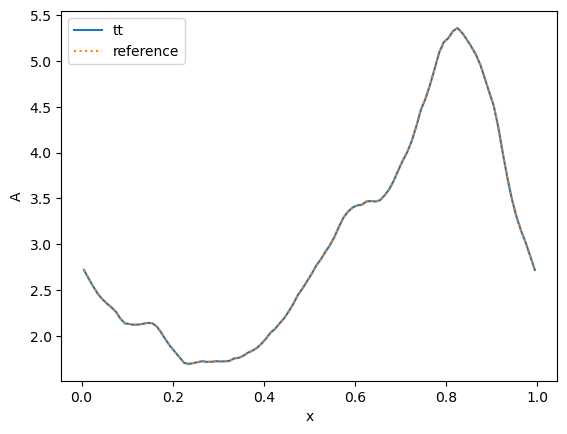

In [16]:
N_MC = 500

def RMS(x, **kwargs):
  return np.sqrt(np.mean(np.square(x), **kwargs))

errs = np.zeros(N_MC)
for i in range(N_MC):
  # eval TT-approx of coeff
  y = rng.integers(0, Ny, n_a_param)
  C_eval = np.ravel(C_a[:, 0, *y])

  X = np.hstack([np.arange(Nx).reshape((-1,1)), np.zeros((Nx,1)), np.tile(y, [Nx,1])])
  # X = np.hstack([np.arange(Nx).reshape((-1,1)), np.zeros((Nx,1)), np.tile(y, [Nx,1])])
  C_true = cfun(X)

  errs[i] = RMS(C_eval-C_true)

print(f'RMS l2 err = {RMS(errs):.2e}')

fig, ax = plt.subplots()

x = (np.arange(0, Nx) + .5) / Nx
ax.plot(x, C_eval, label='tt')
ax.plot(x, C_true, ls='dotted', label="reference")
ax.set_xlabel('x')
ax.set_ylabel('A')
ax.legend()

In [17]:
# tensor for convection
C_v = TreeBasedTensor.ones(tree, (1,) + param_shape, dtype=torch.float64)
C_v.cores[C_v.tree.dim2leaf(1)] = torch.linspace(v_min,v_max, Ny, dtype=torch.float64).reshape(-1,1)
# C_v.cores[C_v.tree.dim2leaf(1)] = torch.zeros(Ny, dtype=torch.float64).reshape(-1,1)

# helper tensor that is constant 1
C_const = TreeBasedTensor.ones(tree, (1,) + param_shape, dtype=torch.float64)
C_const2 = TreeBasedTensor.ones(tree, (1,) + param_shape, dtype=torch.float64)

### ALS-cross test

In [18]:

import cProfile

test = TreeALSCross(
  [C_a, C_v, C_const],
  [C_const],
  PDE_fun,
  rinit=0,
  verbose=1,
  kickrank=10
  )

# stats = cProfile.run('test.run(n_iter=5)', 'profile.prof')
test.run(n_iter=3)

u = test.get_tensor()

Init finished
= swp=0
= swp=0 finished, max_dx=6.34e+45
= swp=1
= swp=1 finished, max_dx=3.69e-02
= swp=2
= swp=2 finished, max_dx=7.43e-04


In [19]:
# import pstats
# from pstats import SortKey
# import subprocess
# p = pstats.Stats('profile.prof')
# p.strip_dirs().sort_stats('cumtime').print_stats()
# subprocess.run('gprof2dot -f pstats profile.prof | dot -Tpng -o output.png', shell=True)

### Test ALS-cross accuracy

Compare ALS cross approximation vs PDE solution for a random sample

RMS l2 err = 1.87e-03
RMS l2 err with approx coeff = 3.15e-04
example
l2 err = 2.39e-03
l2 err to approx coeff = 2.27e-03


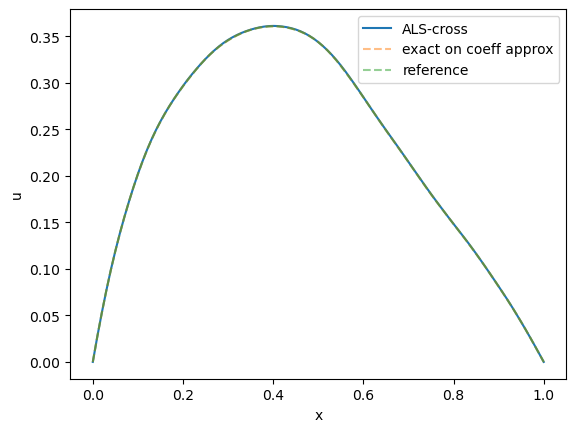

In [21]:
N_MC = 500
err = 0
err_c = 0

for n in range(N_MC):
  # get random parameter
  y = rng.integers(0, Ny, n_param)
  X = np.hstack([np.arange(Nx).reshape((-1,1)), np.tile(y, [Nx,1])])

  C_a_true = cfun(X) # compute true coeff
  v_true = np.linspace(v_min,v_max,Ny)[y[0]]

  U = PDE_fun.solve([torch.from_numpy(C_a_true).reshape(-1,1), v_true * torch.ones((1,1)), torch.zeros((1,1))], [torch.zeros((1,1))]) # solve PDE
  U = np.ravel(U)

  # eval ALS-cross
  U_eval = np.ravel(u[:, *y])
  err += np.sum(np.square(U - U_eval))

  C_eval = np.ravel(C_a[:, *y[:]])
  U_c = PDE_fun.solve([torch.from_numpy(C_eval).reshape(-1,1), v_true * torch.ones((1,1)), torch.zeros((1,1))], [torch.zeros((1,1))]) # solve PDE
  U_c = np.ravel(U_c)
  err_c += np.sum(np.square(U - U_c))

err = np.sqrt(err / N_MC)
err_c = np.sqrt(err_c / N_MC)

print(f'RMS l2 err = {err:.2e}')
print(f'RMS l2 err with approx coeff = {err_c:.2e}')

fig, ax = plt.subplots()

x = np.arange(0, Nx+1) / Nx
ax.plot(x, U_eval, label='ALS-cross')
ax.plot(x, U_c, ls='dashed', label='exact on coeff approx', alpha=.5)
ax.plot(x, U, ls='dashed', label='reference', alpha=.5)
ax.set_xlabel('x')
ax.set_ylabel('u')
ax.legend()

print('example')
print(f'l2 err = {np.linalg.norm(U-U_eval):.2e}')
print(f'l2 err to approx coeff = {np.linalg.norm(U_c-U_eval):.2e}')